In [3]:
import cv2
import os
import time

# --- CONFIGURATION DES CHEMINS ---
BASE_PATH = r"C:\Users\PC\Documents\Active_Learning\videos_B"

def enregistrer_geste(session, geste, duree_secondes):
    cap = cv2.VideoCapture(0)
    save_dir = os.path.join(BASE_PATH, session, geste)
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n🎥 Session: {session.upper()} | Geste: {geste}")
    print(f"Préparez-vous... Enregistrement de {duree_secondes}s dans 10 secondes.")
    time.sleep(10)
    
    start_time = time.time()
    count = 0
    
    while (time.time() - start_time) < duree_secondes:
        ret, frame = cap.read()
        if not ret: break
        
        # Redimensionnement immédiat à 224x224 (Format ResNet-18) 
        frame_resized = cv2.resize(frame, (224, 224))
        
        # Sauvegarde d'environ 5 images par seconde pour éviter les doublons inutiles
        if count % 6 == 0: 
            img_name = f"img_{int(time.time()*1000)}.jpg"
            cv2.imwrite(os.path.join(save_dir, img_name), frame_resized)
        
        # Affichage
        cv2.putText(frame, f"REC {geste} - {int(time.time()-start_time)}s", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        cv2.imshow("Capture Domaine B", frame)
        count += 1
        if cv2.waitKey(1) & 0xFF == ord('q'): break
            
    cap.release()
    cv2.destroyAllWindows()
    print(f"✅ Terminé pour {geste}")

# --- EXÉCUTION DU PLAN DE TOURNAGE ---

# --- EXÉCUTION DU PLAN DE TOURNAGE CORRIGÉ ---

# 1. Pour le TEST B (6 vidéos de 15s au total)
# On fait 2 passages pour avoir 2 vidéos par geste comme demandé
for i in range(2): 
    for g in ["0_Pierre", "1_Feuille", "2_Ciseaux"]:
        print(f"\nVague de capture {i+1} pour le TEST (Changez de fond/lumière !)")
        enregistrer_geste("test", g, 15) 

# 2. Pour le POOL (12 vidéos de 10s au total)
# On change range(2) en range(4) pour avoir 4 vidéos par geste
for i in range(4): 
    for g in ["0_Pierre", "1_Feuille", "2_Ciseaux"]:
        print(f"\nVague de capture {i+1} pour le Pool")
        enregistrer_geste("pool", g, 10)


Vague de capture 1 pour le TEST (Changez de fond/lumière !)

🎥 Session: TEST | Geste: 0_Pierre
Préparez-vous... Enregistrement de 15s dans 10 secondes.
✅ Terminé pour 0_Pierre

Vague de capture 1 pour le TEST (Changez de fond/lumière !)

🎥 Session: TEST | Geste: 1_Feuille
Préparez-vous... Enregistrement de 15s dans 10 secondes.
✅ Terminé pour 1_Feuille

Vague de capture 1 pour le TEST (Changez de fond/lumière !)

🎥 Session: TEST | Geste: 2_Ciseaux
Préparez-vous... Enregistrement de 15s dans 10 secondes.
✅ Terminé pour 2_Ciseaux

Vague de capture 2 pour le TEST (Changez de fond/lumière !)

🎥 Session: TEST | Geste: 0_Pierre
Préparez-vous... Enregistrement de 15s dans 10 secondes.
✅ Terminé pour 0_Pierre

Vague de capture 2 pour le TEST (Changez de fond/lumière !)

🎥 Session: TEST | Geste: 1_Feuille
Préparez-vous... Enregistrement de 15s dans 10 secondes.
✅ Terminé pour 1_Feuille

Vague de capture 2 pour le TEST (Changez de fond/lumière !)

🎥 Session: TEST | Geste: 2_Ciseaux
Préparez-vou

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\PC\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
import sys
!{sys.executable} -m pip install torchvision torch


  Using cached torchvision-0.25.0-cp310-cp310-win_amd64.whl (3.7 MB)


You should consider upgrading via the 'c:\Users\PC\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
# =================================================================
# ÉTAPE 3 : PRÉPARATION ET CHARGEMENT DES DONNÉES (A et B)
# =================================================================

import os
import cv2
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import torchvision.transforms as transforms

# --- 1. CONFIGURATION DES CHEMINS ---
BASE_DIR = Path(r"C:\Users\PC\Documents\Active_Learning")
PATH_DOMAIN_A = BASE_DIR / "archive"
PATH_DOMAIN_B = BASE_DIR / "videos_B" 

# On sépare les noms de dossiers pour gérer la différence de langue/nommage
CLASSES_A = ["rock", "paper", "scissors"]
LABEL_MAP_A = {"rock": 0, "paper": 1, "scissors": 2}

CLASSES_B = ["0_Pierre", "1_Feuille", "2_Ciseaux"]
LABEL_MAP_B = {"0_Pierre": 0, "1_Feuille": 1, "2_Ciseaux": 2}

IMG_SIZE = (224, 224) 

# --- 2. FONCTION DE CHARGEMENT GÉNÉRIQUE ---
def load_images_local(root_path, subset, current_classes, current_label_map, resize=IMG_SIZE):
    X, y = [], []
    subset_path = Path(root_path) / subset
    
    print(f"Chargement de {subset} dans {root_path}...")
    if not subset_path.exists():
        print(f"⚠️ Dossier inexistant : {subset_path}")
        return np.array(X), np.array(y)

    for cls_name in current_classes:
        cls_folder = subset_path / cls_name
        if not cls_folder.exists(): 
            print(f"   ⚠️ Dossier {cls_name} non trouvé dans {subset}")
            continue

        for img_name in os.listdir(cls_folder):
            img_path = cls_folder / img_name
            img = cv2.imread(str(img_path))
            if img is not None:
                # ResNet attend du RGB (OpenCV lit en BGR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, resize)
                X.append(img)
                y.append(current_label_map[cls_name])

    return np.array(X), np.array(y)

# --- 3. CHARGEMENT RÉEL DES DONNÉES ---
X_train_A, y_train_A = load_images_local(PATH_DOMAIN_A, "train", CLASSES_A, LABEL_MAP_A)
X_test_A, y_test_A   = load_images_local(PATH_DOMAIN_A, "test", CLASSES_A, LABEL_MAP_A)

X_pool_B, y_pool_B   = load_images_local(PATH_DOMAIN_B, "pool", CLASSES_B, LABEL_MAP_B)
X_test_B, y_test_B   = load_images_local(PATH_DOMAIN_B, "test", CLASSES_B, LABEL_MAP_B)

# --- 4. CONVERSION EN TENSEURS PYTORCH ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def to_tensor(X, y):
    if len(X) == 0: return None
    
    # Transformation en tenseur (Batch, Channel, Height, Width) et normalisation 0-1
    tensor_x = torch.Tensor(X).permute(0, 3, 1, 2) / 255.0
    
    # Normalisation spécifique à ResNet (Moyenne et écart-type d'ImageNet)
    # Cela aide le modèle pré-entraîné à reconnaître les formes
    norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    tensor_x = torch.stack([norm(t) for t in tensor_x])
    
    tensor_y = torch.LongTensor(y)
    return TensorDataset(tensor_x.to(device), tensor_y.to(device))

# Création des Datasets
train_A_ds = to_tensor(X_train_A, y_train_A)
test_A_ds  = to_tensor(X_test_A, y_test_A)
pool_B_ds  = to_tensor(X_pool_B, y_pool_B)
test_B_ds  = to_tensor(X_test_B, y_test_B)

print(f"\n📊 RÉSUMÉ DES DONNÉES (Conforme Tableau 2 du Proposal) :")
print(f"Domaine A (Kaggle) : Train={len(X_train_A)}, Test={len(X_test_A)}")
print(f"Domaine B (Webcam) : Pool={len(X_pool_B)}, Test={len(X_test_B)}")

Chargement de train dans C:\Users\PC\Documents\Active_Learning\archive...
Chargement de test dans C:\Users\PC\Documents\Active_Learning\archive...
Chargement de pool dans C:\Users\PC\Documents\Active_Learning\videos_B...
Chargement de test dans C:\Users\PC\Documents\Active_Learning\videos_B...

📊 RÉSUMÉ DES DONNÉES (Conforme Tableau 2 du Proposal) :
Domaine A (Kaggle) : Train=1020, Test=540
Domaine B (Webcam) : Pool=741, Test=619


In [5]:
# =================================================================
# BLOC 2 : MODÈLE, BASELINE ET PARAMÈTRES
# =================================================================

import torch
import torch.nn as nn
import torchvision.models as models
import time

# --- 1. DÉFINITION DU MODÈLE (ResNet-18) ---
class GestureClassifier(nn.Module):
    def __init__(self):
        super(GestureClassifier, self).__init__()
        # Chargement des poids ImageNet (transfert learning)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Modification de la dernière couche pour 3 classes (Pierre, Feuille, Ciseaux)
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, 3) 

    def forward(self, x):
        return self.resnet(x)

# --- 2. FONCTIONS D'ENTRAÎNEMENT ET ÉVALUATION ---

def train_model(model, train_loader, criterion, optimizer, epochs=5, device='cpu'):
    model.to(device)
    model.train() # Mode entraînement
    
    print(f"🚀 Début de l'entraînement ({epochs} époques)...")
    start_time = time.time()
    
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_acc = 100. * correct / total
        print(f"   Époque {epoch+1}/{epochs} | Loss: {running_loss/total:.4f} | Acc Train: {epoch_acc:.2f}%")
        
    print(f"✅ Entraînement terminé en {time.time() - start_time:.1f}s")
    return model

def evaluate_model(model, loader, name="Test"):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    acc = 100. * correct / total
    print(f"📊 Performance sur {name} : {acc:.2f}%")
    return acc

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- 3. INITIALISATION ET BASELINE ---

# Initialisation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GestureClassifier().to(device)

# Affichage du nombre de paramètres (Demandé Point 3 du PDF)
print(f"🔢 Nombre de paramètres entraînables : {count_parameters(model):,}")

# Préparation des loaders
train_A_loader = DataLoader(train_A_ds, batch_size=32, shuffle=True)
test_A_loader  = DataLoader(test_A_ds, batch_size=32, shuffle=False)
test_B_loader  = DataLoader(test_B_ds, batch_size=32, shuffle=False)

# Optimiseur ADAMW (Exigence Prof)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# --- 4. ENTRAÎNEMENT BASELINE (DOMAINE A UNIQUEMENT) ---
print("\n" + "="*50)
print("PHASE 1 : ENTRAÎNEMENT BASELINE (DOMAINE A)")
print("="*50)

model = train_model(model, train_A_loader, criterion, optimizer, epochs=5, device=device)

# Sauvegarde du modèle de base (il servira de point de départ pour toutes les expériences)
baseline_path = "resnet18_baseline.pth"
torch.save(model.state_dict(), baseline_path)
print(f"💾 Modèle de base sauvegardé : {baseline_path}")

# --- 5. ÉVALUATION INITIALE (DIAGNOSTIC) ---
print("\n" + "="*50)
print("PHASE 2 : ÉVALUATION INITIALE (AVANT ACTIVE LEARNING)")
print("="*50)

acc_A = evaluate_model(model, test_A_loader, "Domaine A (Kaggle)")
acc_B = evaluate_model(model, test_B_loader, "Domaine B (Webcam)")

# Analyse automatique pour le rapport
if acc_A > acc_B + 20:
    print("\n💡 ANALYSE : Écart important détecté (Domain Gap).")
    print("   Le modèle est bon sur A mais mauvais sur B.")
    print("   C'est la situation idéale pour tester l'Active Learning !")
else:
    print("\n💡 ANALYSE : Les performances sont proches ou déjà élevées.")
    print("   L'Active Learning apportera moins de gain visible.")

# Sauvegarde des résultats pour le tableau du rapport
baseline_results = {
    "Acc_A": acc_A,
    "Acc_B": acc_B,
    "Time": time.time(),
    "Params": count_parameters(model)
}

🔢 Nombre de paramètres entraînables : 11,178,051

PHASE 1 : ENTRAÎNEMENT BASELINE (DOMAINE A)
🚀 Début de l'entraînement (5 époques)...
   Époque 1/5 | Loss: 0.3295 | Acc Train: 88.43%
   Époque 2/5 | Loss: 0.0172 | Acc Train: 99.71%
   Époque 3/5 | Loss: 0.0049 | Acc Train: 100.00%
   Époque 4/5 | Loss: 0.0038 | Acc Train: 100.00%
   Époque 5/5 | Loss: 0.0021 | Acc Train: 100.00%
✅ Entraînement terminé en 960.9s
💾 Modèle de base sauvegardé : resnet18_baseline.pth

PHASE 2 : ÉVALUATION INITIALE (AVANT ACTIVE LEARNING)
📊 Performance sur Domaine A (Kaggle) : 84.44%
📊 Performance sur Domaine B (Webcam) : 58.64%

💡 ANALYSE : Écart important détecté (Domain Gap).
   Le modèle est bon sur A mais mauvais sur B.
   C'est la situation idéale pour tester l'Active Learning !


In [6]:
# =================================================================
# BLOC 3 : STRATÉGIES DE SÉLECTION (CERVEAU DE L'AL)
# =================================================================

import numpy as np
import torch
from sklearn.metrics import pairwise_distances

# --- 1. STRATÉGIE ALÉATOIRE (RÉFÉRENCE) ---
def random_selection(model, pool_data, n_samples, device):
    """
    Sélectionne n_samples au hasard dans le pool.
    C'est la baseline à battre.
    """
    n_pool = len(pool_data)
    indices = np.random.choice(n_pool, n_samples, replace=False)
    return indices

# --- 2. STRATÉGIE BASÉE SUR L'INCERTITUDE (MARGIN SAMPLING) ---
def uncertainty_selection(model, pool_data, n_samples, device):
    """
    Sélectionne les images où le modèle hésite le plus 
    (différence entre les 2 meilleures probabilités est faible).
    """
    model.eval()
    pool_loader = DataLoader(pool_data, batch_size=64, shuffle=False)
    all_margins = []
    
    with torch.no_grad():
        for inputs, _ in pool_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # On trie les probabilités
            probs_sorted, _ = torch.sort(probs, descending=True)
            
            # Marge = Top1 - Top2. Si proche de 0, le modèle hésite.
            margins = probs_sorted[:, 0] - probs_sorted[:, 1]
            all_margins.extend(margins.cpu().numpy())
            
    # On prend les indices des marges les plus petites
    indices = np.argsort(all_margins)[:n_samples]
    return indices

# --- 3. STRATÉGIE BASÉE SUR LA DIVERSITÉ (CORESET) ---
def get_embeddings(model, dataset, device):
    """
    Extrait les features internes du modèle (avant la couche finale).
    Nécessaire pour calculer la diversité.
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    embeddings = []
    
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            # Astuce : on prend la sortie de la couche 'avgpool' de ResNet
            # C'est le vecteur de caractéristiques compressé
            x = model.resnet.conv1(inputs)
            x = model.resnet.bn1(x)
            x = model.resnet.relu(x)
            x = model.resnet.maxpool(x)
            x = model.resnet.layer1(x)
            x = model.resnet.layer2(x)
            x = model.resnet.layer3(x)
            x = model.resnet.layer4(x)
            x = model.resnet.avgpool(x)
            x = torch.flatten(x, 1)
            embeddings.append(x.cpu().numpy())
            
    return np.vstack(embeddings)

def diversity_selection(model, pool_data, n_samples, device):
    """
    Sélectionne des images différentes entre elles (éloignées dans l'espace des features).
    Utilise l'algorithme K-Center Greedy.
    """
    # 1. Obtenir les features
    embeddings = get_embeddings(model, pool_data, device)
    
    # 2. K-Center Greedy simplifié
    # On commence par prendre un point au hasard, puis on prend le plus loin, etc.
    # Pour simplifier ici, on utilise une méthode de sous-échantillonnage distant
    
    # On choisit le premier au hasard
    selected_indices = [np.random.randint(0, len(embeddings))]
    
    for _ in range(n_samples - 1):
        # Calculer la distance de tous les points aux points déjà sélectionnés
        # On garde la distance minimale de chaque point au set sélectionné
        selected_embs = embeddings[selected_indices]
        
        # Distance de chaque point du pool aux points sélectionnés
        dists = pairwise_distances(embeddings, selected_embs, metric='euclidean')
        min_dists = np.min(dists, axis=1)
        
        # Le point le plus éloigné est le plus "divers"
        new_idx = np.argmax(min_dists)
        selected_indices.append(new_idx)
        
    return np.array(selected_indices)

# --- 4. STRATÉGIE MIXTE (COMBINAISON) ---
def hybrid_selection(model, pool_data, n_samples, device):
    """
    Combine Incertitude et Diversité.
    1. Filtre les 20% les plus incertains.
    2. Parmi eux, prend les plus divers.
    """
    n_pool = len(pool_data)
    n_uncertainty = int(n_pool * 0.2) # On prend les 20% plus incertains
    
    # Étape 1 : Trouver les indices incertains
    uncertain_indices = uncertainty_selection(model, pool_data, n_uncertainty, device)
    
    # Étape 2 : Calculer la diversité parmi ces incertains
    # On va utiliser K-Center uniquement sur ce sous-ensemble
    
    # Créer un sous-ensemble des données pour extraire les embeddings
    subset_indices = uncertain_indices
    
    # On réutilise la logique de diversité mais sur le subset
    embeddings = get_embeddings(model, pool_data, device)
    subset_embs = embeddings[subset_indices]
    
    # Greedy K-Center sur le subset
    # On prend un point au hasard dans le subset pour commencer
    local_selected = [0] 
    for _ in range(n_samples - 1):
        selected_embs = subset_embs[local_selected]
        dists = pairwise_distances(subset_embs, selected_embs)
        min_dists = np.min(dists, axis=1)
        # On interdit de reprendre les mêmes (distance 0)
        min_dists[local_selected] = -1 
        new_idx = np.argmax(min_dists)
        local_selected.append(new_idx)
        
    # On map les indices locaux du subset vers les indices globaux du pool
    final_indices = subset_indices[local_selected]
    
    return final_indices

print("✅ Toutes les stratégies de sélection sont définies.")
print("   - Random")
print("   - Uncertainty (Margin)")
print("   - Diversity (Coreset)")
print("   - Hybrid (Uncertainty + Diversity)")

✅ Toutes les stratégies de sélection sont définies.
   - Random
   - Uncertainty (Margin)
   - Diversity (Coreset)
   - Hybrid (Uncertainty + Diversity)


In [8]:
# =================================================================
# BLOC 4 : BOUCLE D'EXPÉRIENCE PRINCIPALE (AVEC REPRISE)
# =================================================================

import pandas as pd
import numpy as np
import torch
import os
from torch.utils.data import DataLoader

# --- PARAMÈTRES DE L'EXPÉRIENCE ---
BUDGET_RATIOS = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50]
N_RUNS = 3  # Nombre de répétitions
EPOCHS_AL = 3 # Époques pour l'adaptation

# --- DÉFINITION DE LA 2ÈME STRATÉGIE MIXTE (MANQUANTE) ---
def weighted_hybrid_selection(model, pool_data, n_samples, device):
    """
    Stratégie Mixte 2 : Score pondéré.
    Score = (Poids Incertitude * Score Incertitude) + (Poids Diversité * Score Diversité)
    """
    model.eval()
    pool_loader = DataLoader(pool_data, batch_size=64, shuffle=False)
    all_uncertainties = []
    
    # 1. Calcul Incertitude
    with torch.no_grad():
        for inputs, _ in pool_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            probs_sorted, _ = torch.sort(probs, descending=True)
            margins = probs_sorted[:, 0] - probs_sorted[:, 1]
            scores = 1.0 - margins.cpu().numpy() # Petit marge = gros score
            all_uncertainties.extend(scores)
            
    uncertainty_scores = np.array(all_uncertainties)
    
    # 2. Calcul Diversité (Distance au centre du pool)
    embeddings = get_embeddings(model, pool_data, device)
    center = np.mean(embeddings, axis=0)
    dists = np.linalg.norm(embeddings - center, axis=1)
    diversity_scores = (dists - dists.min()) / (dists.max() - dists.min() + 1e-6)
    
    # 3. Combinaison
    final_scores = 0.5 * uncertainty_scores + 0.5 * diversity_scores
    indices = np.argsort(final_scores)[-n_samples:]
    return indices

# --- LISTE DES STRATÉGIES (MISE À JOUR) ---
strategies = {
    "Random": random_selection,
    "Uncertainty": uncertainty_selection,
    "Diversity": diversity_selection,
    "Hybrid": hybrid_selection,            # Mixte 1 (Filtrage)
    "Weighted_Hybrid": weighted_hybrid_selection # Mixte 2 (Pondération)
}

# Fichier de sauvegarde
csv_file = "active_learning_results.csv"

# --- SYSTÈME DE REPRISE (Pour ne pas tout recommencer) ---
# Si le fichier existe déjà, on charge ce qui a été fait
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    print(f"📂 Fichier existant détecté. {len(df_existing)} entrées déjà calculées.")
else:
    # Création du fichier avec l'en-tête si nouveau
    with open(csv_file, "w") as f:
        f.write("Strategy,Run,Budget,Accuracy_B\n")
    df_existing = pd.DataFrame(columns=["Strategy", "Run", "Budget", "Accuracy_B"])

print(f"🚧 DÉBUT / REPRISE DES EXPÉRIENCES.")
print(f"⏳ Temps estimé : Long (CPU). Patience...")

# --- BOUCLE PRINCIPALE ---

for strategy_name, strategy_func in strategies.items():
    print(f"\n{'='*60}")
    print(f"STRATÉGIE EN COURS : {strategy_name}")
    print(f"{'='*60}")
    
    for run in range(1, N_RUNS + 1):
        # Vérification rapide : ce run est-il déjà fini ?
        # On regarde si la dernière ligne de ce run (Budget 0.5) est dans le CSV
        mask = (df_existing["Strategy"] == strategy_name) & (df_existing["Run"] == run) & (df_existing["Budget"] == 0.50)
        
        if not df_existing.empty and mask.any():
            print(f"   ✅ Run {run}/{N_RUNS} déjà effectué. Passage au suivant.")
            continue
            
        print(f"\n--- Run {run}/{N_RUNS} pour {strategy_name} ---")
        
        # 1. RÉINITIALISATION DU MODÈLE
        model.load_state_dict(torch.load("resnet18_baseline.pth"))
        model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        
        # 2. RÉINITIALISATION DES DONNÉES
        X_train_current = X_train_A.copy()
        y_train_current = y_train_A.copy()
        
        X_pool_current = X_pool_B.copy()
        y_pool_current = y_pool_B.copy()
        
        previous_budget_count = 0
        
        # 3. BOUCLE SUR LES BUDGETS
        for ratio in BUDGET_RATIOS:
            
            # Vérification : Ce point précis est-il déjà dans le CSV ?
            point_mask = (df_existing["Strategy"] == strategy_name) & (df_existing["Run"] == run) & (df_existing["Budget"] == ratio)
            
            if not df_existing.empty and point_mask.any():
                # Si le point existe, on met juste à jour les variables pour continuer la suite
                # On charge l'accuracy enregistrée juste pour info
                saved_acc = df_existing[point_mask]["Accuracy_B"].values[0]
                print(f"  -> Budget {ratio*100:.0f}% déjà fait (Acc: {saved_acc:.2f}%). On continue...")
                
                # IMPORTANT : Il faut remettre le compte à jour pour que le prochain step soit correct
                previous_budget_count = int(len(X_pool_B) * ratio)
                continue

            # Calcul du nombre d'images à prélever
            target_count = int(len(X_pool_B) * ratio)
            n_query = target_count - previous_budget_count
            
            if n_query <= 0: continue
            
            print(f"  -> Budget {ratio*100:.0f}% : Sélection de {n_query} images...")
            
            # A. SÉLECTION
            temp_pool_ds = to_tensor(X_pool_current, y_pool_current)
            indices = strategy_func(model, temp_pool_ds, n_query, device)
            
            # B. MISE À JOUR
            X_selected = X_pool_current[indices]
            y_selected = y_pool_current[indices]
            
            X_train_current = np.concatenate([X_train_current, X_selected])
            y_train_current = np.concatenate([y_train_current, y_selected])
            
            X_pool_current = np.delete(X_pool_current, indices, axis=0)
            y_pool_current = np.delete(y_pool_current, indices, axis=0)
            
            previous_budget_count = target_count
            
            # C. ENTRAÎNEMENT
            train_loader = DataLoader(to_tensor(X_train_current, y_train_current), batch_size=32, shuffle=True)
            model = train_model(model, train_loader, criterion, optimizer, epochs=EPOCHS_AL, device=device)
            
            # D. ÉVALUATION
            acc_B = evaluate_model(model, test_B_loader, name=f"{strategy_name} Run{run}")
            
            # E. SAUVEGARDE
            with open(csv_file, "a") as f:
                f.write(f"{strategy_name},{run},{ratio},{acc_B}\n")
            
            # On recharge le dataframe pour que la vérification suivante soit à jour
            df_existing = pd.read_csv(csv_file)

print("\n" + "="*60)
print("✅ TOUTES LES EXPÉRIENCES SONT TERMINÉES.")
print(f"📊 Fichier de résultats final : {csv_file}")
print("="*60)

📂 Fichier existant détecté. 19 entrées déjà calculées.
🚧 DÉBUT / REPRISE DES EXPÉRIENCES.
⏳ Temps estimé : Long (CPU). Patience...

STRATÉGIE EN COURS : Random
   ✅ Run 1/3 déjà effectué. Passage au suivant.
   ✅ Run 2/3 déjà effectué. Passage au suivant.
   ✅ Run 3/3 déjà effectué. Passage au suivant.

STRATÉGIE EN COURS : Uncertainty

--- Run 1/3 pour Uncertainty ---
  -> Budget 1% déjà fait (Acc: 52.34%). On continue...
  -> Budget 2% : Sélection de 7 images...
🚀 Début de l'entraînement (3 époques)...
   Époque 1/3 | Loss: 0.0138 | Acc Train: 99.51%
   Époque 2/3 | Loss: 0.0338 | Acc Train: 98.83%
   Époque 3/3 | Loss: 0.0391 | Acc Train: 99.12%
✅ Entraînement terminé en 539.5s
📊 Performance sur Uncertainty Run1 : 50.89%
  -> Budget 5% : Sélection de 23 images...
🚀 Début de l'entraînement (3 époques)...
   Époque 1/3 | Loss: 0.0593 | Acc Train: 97.71%
   Époque 2/3 | Loss: 0.0102 | Acc Train: 99.71%
   Époque 3/3 | Loss: 0.0031 | Acc Train: 100.00%
✅ Entraînement terminé en 533.4s
📊

📊 Données chargées : 90 entrées trouvées.
📸 Courbe sauvegardée sous : active_learning_curves.png


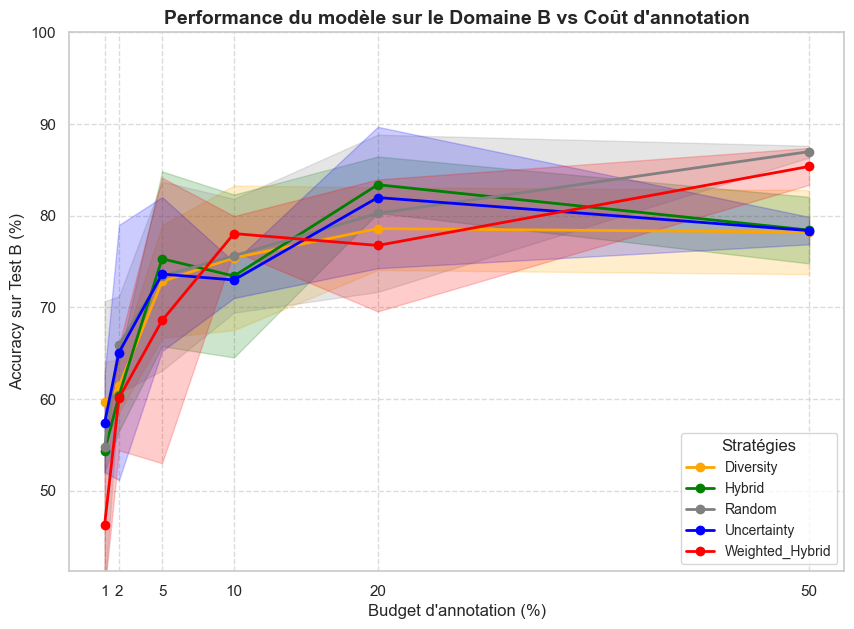


📋 SYNTHÈSE DES RÉSULTATS (À COPIER DANS LE RAPPORT)
🔹 Diversity : Départ 59.61% -> Fin 78.19% (Gain: +18.58%)
🔹 Hybrid : Départ 54.28% -> Fin 78.41% (Gain: +24.12%)
🔹 Random : Départ 54.71% -> Fin 86.97% (Gain: +32.26%)
🔹 Uncertainty : Départ 57.35% -> Fin 78.35% (Gain: +21.00%)
🔹 Weighted_Hybrid : Départ 46.20% -> Fin 85.35% (Gain: +39.15%)

💡 Analyse des stratégies :
   - Meilleure performance à faible budget (1%) : Diversity
   - Meilleure performance à fort budget (50%) : Random


In [9]:
# =================================================================
# BLOC 5 : GÉNÉRATION DES COURBES ET ANALYSE FINALE
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- 1. CHARGEMENT DES DONNÉES ---
csv_file = "active_learning_results.csv"
df = pd.read_csv(csv_file)

print(f"📊 Données chargées : {len(df)} entrées trouvées.")

# --- 2. CALCUL DES MOYENNES ET INTERVALLES DE CONFIANCE ---
# On groupe par Stratégie et Budget pour calculer la moyenne et l'écart-type
summary = df.groupby(['Strategy', 'Budget'])['Accuracy_B'].agg(['mean', 'std', 'count']).reset_index()

# Calcul de l'intervalle de confiance (95%)
# Formule : 1.96 * (écart-type / sqrt(nombre_de_runs))
summary['ci'] = 1.96 * (summary['std'] / np.sqrt(summary['count']))

# --- 3. PARAMÈTRES D'AFFICHAGE (STYLE PROFESSIONNEL) ---
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid") # Style scientifique propre

# Palette de couleurs pour distinguer les stratégies
colors = {
    "Random": "gray",
    "Uncertainty": "blue",
    "Diversity": "orange",
    "Hybrid": "green",
    "Weighted_Hybrid": "red"
}

# --- 4. TRAÇAGE DES COURBES ---
strategies_to_plot = summary['Strategy'].unique()

for strat in strategies_to_plot:
    data = summary[summary['Strategy'] == strat]
    
    # Tracer la ligne principale (Moyenne)
    plt.plot(data['Budget'] * 100, data['mean'], 
             marker='o', 
             label=strat, 
             color=colors.get(strat, 'black'),
             linewidth=2)
    
    # Tracer la "zone d'ombre" (Intervalle de confiance)
    plt.fill_between(data['Budget'] * 100, 
                     data['mean'] - data['ci'], 
                     data['mean'] + data['ci'], 
                     color=colors.get(strat, 'black'), 
                     alpha=0.2) # Transparence

# --- 5. MISE EN FORME (AXES, TITRES, LÉGENDE) ---
plt.title("Performance du modèle sur le Domaine B vs Coût d'annotation", fontsize=14, fontweight='bold')
plt.xlabel("Budget d'annotation (%)", fontsize=12)
plt.ylabel("Accuracy sur Test B (%)", fontsize=12)
plt.legend(title="Stratégies", loc='lower right', fontsize=10)

# Forcer l'axe X à afficher les pourcentages définis
plt.xticks([1, 2, 5, 10, 20, 50]) 
plt.ylim(bottom=min(summary['mean']) - 5, top=100) # Espace pour bien voir

# Grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.7)

# --- 6. SAUVEGARDE ET AFFICHAGE ---
plot_filename = "active_learning_curves.png"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"📸 Courbe sauvegardée sous : {plot_filename}")

plt.show()

# --- 7. ANALYSE AUTOMATIQUE POUR LE RAPPORT ---
print("\n" + "="*60)
print("📋 SYNTHÈSE DES RÉSULTATS (À COPIER DANS LE RAPPORT)")
print("="*60)

# Performance initiale (Budget 1%) vs Finale (Budget 50%)
for strat in strategies_to_plot:
    data_strat = summary[summary['Strategy'] == strat]
    if len(data_strat) > 0:
        first_point = data_strat.iloc[0]['mean']
        last_point = data_strat.iloc[-1]['mean']
        print(f"🔹 {strat} : Départ {first_point:.2f}% -> Fin {last_point:.2f}% (Gain: +{last_point-first_point:.2f}%)")

print("\n💡 Analyse des stratégies :")
best_start_strat = summary[summary['Budget'] == 0.01].sort_values(by='mean', ascending=False).iloc[0]['Strategy']
best_end_strat = summary[summary['Budget'] == 0.50].sort_values(by='mean', ascending=False).iloc[0]['Strategy']

print(f"   - Meilleure performance à faible budget (1%) : {best_start_strat}")
print(f"   - Meilleure performance à fort budget (50%) : {best_end_strat}")
print("="*60)

🔍 Sélection des images les plus INCERTAINES...


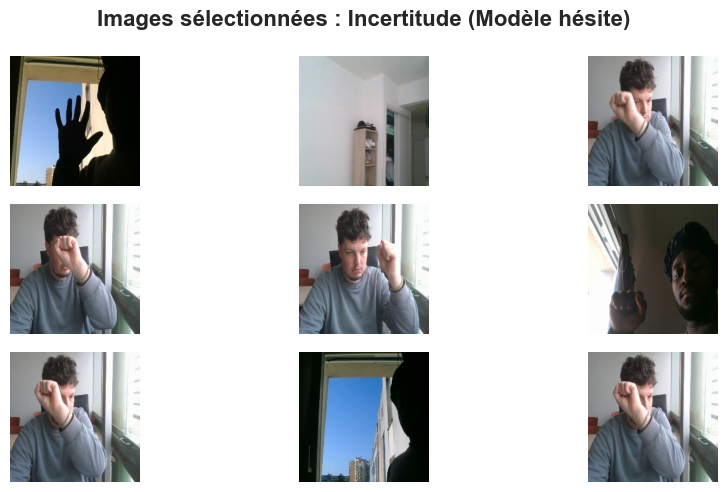

🔍 Sélection des images les plus DIVERSES...


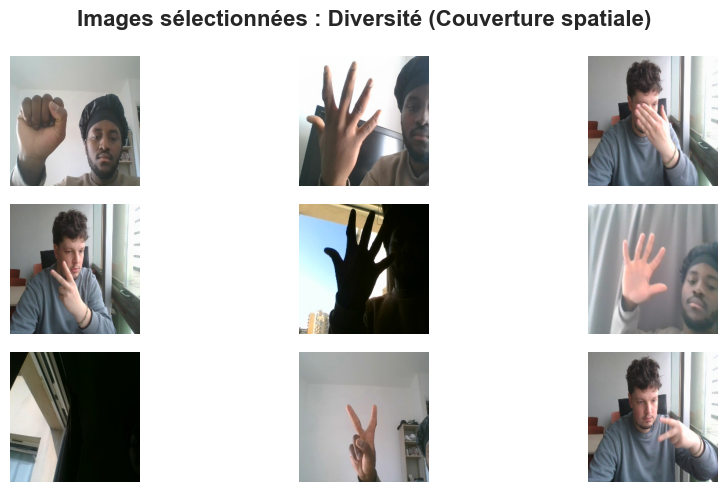

🔍 Sélection aléatoire (Témoin)...


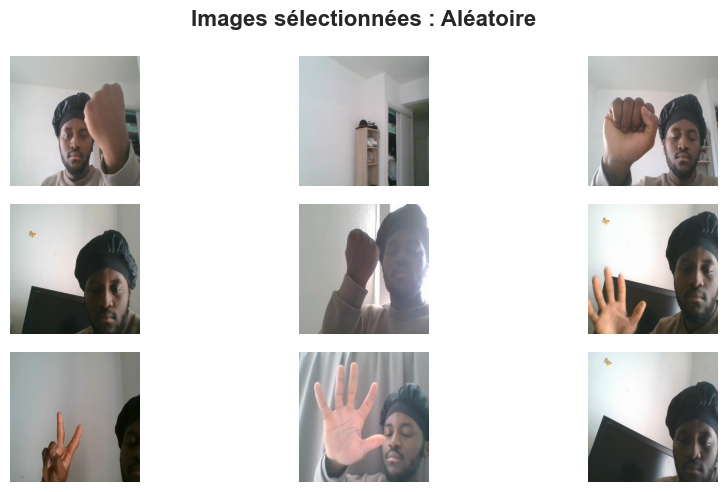


✅ Analyse qualitative terminée.


In [10]:
# =================================================================
# BLOC 6 : ANALYSE QUALITATIVE (VISUALISATION DES CHOIX)
# =================================================================

import matplotlib.pyplot as plt
import random

def show_selected_images(X_pool, indices, title):
    """
    Affiche une grille d'images sélectionnées par une stratégie.
    """
    plt.figure(figsize=(10, 5))
    plt.suptitle(title, fontsize=16, fontweight='bold')
    
    # On prend jusqu'à 9 images max pour l'affichage
    display_indices = indices[:9]
    
    for i, idx in enumerate(display_indices):
        plt.subplot(3, 3, i+1)
        
        # Revenir au format image (H, W, C) et inverser la normalisation pour l'affichage
        img = X_pool[idx]
        
        # Image numpy (H, W, C) - Remettre les valeurs entre 0 et 255 pour affichage correct
        # Tes images X_pool sont déjà en 0-255 RGB normalement
        plt.imshow(img.astype(int))
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# --- 1. Préparation : On prend le modèle Baseline pour simuler une sélection ---
model.load_state_dict(torch.load("resnet18_baseline.pth"))
model.eval()

# On travaille sur le Pool B complet (non annoté au début)
X_pool_full = X_pool_B.copy()
y_pool_full = y_pool_B.copy()
pool_dataset = to_tensor(X_pool_full, y_pool_full)

# Nombre d'images à sélectionner pour l'exemple
N_VISU = 50

# --- 2. SÉLECTION PAR INCERTITUDE ---
print("🔍 Sélection des images les plus INCERTAINES...")
indices_uncertainty = uncertainty_selection(model, pool_dataset, N_VISU, device)
show_selected_images(X_pool_full, indices_uncertainty, "Images sélectionnées : Incertitude (Modèle hésite)")

# --- 3. SÉLECTION PAR DIVERSITÉ ---
print("🔍 Sélection des images les plus DIVERSES...")
indices_diversity = diversity_selection(model, pool_dataset, N_VISU, device)
show_selected_images(X_pool_full, indices_diversity, "Images sélectionnées : Diversité (Couverture spatiale)")

# --- 4. SÉLECTION ALÉATOIRE (Comparaison) ---
print("🔍 Sélection aléatoire (Témoin)...")
indices_random = random.sample(range(len(X_pool_full)), N_VISU)
show_selected_images(X_pool_full, indices_random, "Images sélectionnées : Aléatoire")

print("\n✅ Analyse qualitative terminée.")